
# Laboratorio 4: Proximal Policy Optimization
En este laboratorio utilizaremos la clase PPO de la biblioteca stable_baselines3 para entrenar políticas que resulevan dos problemas.

El primer problema a resolver es que un automóvil aprenda a entrar a una rotonda, según el entorno roundabout-v0, ya implementado.

Este primer problema sirve para familiarizarse con la clase PPO y su entrenamiento.

Luego, en el segundo problema, programaremos nuestro propio sistema (environment) para modelar una dirección asistida para el centrado en el carril.

Este segundo problema esta pensado para que en un futuro puedan usar stable_baselines3 PPO con un problema genérico al que se enfrenten.

Entre medio, las preguntas 4 a 7 sirven para repasar algunas propiedades teóricas de PPO.

In [1]:
!pip install stable-baselines3[extra] highway-env

#Pregunta 1

 En la línea 4 del siguiente código importamos PPO de stable_baselines3  Encuentre la línea de código en stable-baselines3 donde se define el objetivo recortado (clipped objective) y cópiela aquí.


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import highway_env
import warnings
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from matplotlib import animation
import matplotlib.pyplot as plt
import imageio
import base64
from IPython.display import HTML


warnings.filterwarnings("ignore", category=DeprecationWarning)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


#Pregunta 2
En el siguiente código se crea un sistem (environment) de tipo "roundabout-v0".  

Investigue cuál es el estado del sistema, la acción y la recompensa asociada.


In [3]:
# 3. Create and wrap environment
# We pass config to lower the rendering resolution, saving massive amounts of RAM
config = {
    "offscreen_rendering": True,
    "scaling": 1.5 # Lowers the render scale to save memory
}
env = gym.make("roundabout-v0", render_mode="rgb_array")
env.unwrapped.configure(config)
env = Monitor(env)

#Pregunta 3

Ejecute el siguiente código de entrenamiento cambiando el número de neuronas y total_timesteps para explorar cuál es la red más pequeña que resuelve el problema y la cantidad de entrenamiento necesaria.

Note que correr 1000 timesteps puede llevar decenas de minutos dependiendo del poder de cómputo utilizado

In [4]:
# 4. Train the PPO agent


n_cpu = 2
env = make_vec_env(
    "roundabout-v0",
    n_envs=n_cpu,
    vec_env_cls=DummyVecEnv,
    env_kwargs={"render_mode": "rgb_array"}
)
model = PPO(
    policy="MlpPolicy",
    policy_kwargs=dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])]),
    env=env,
    verbose=1,
    learning_rate=5e-4,
    n_steps=64//n_cpu,
    n_epochs=10,
    batch_size=64,
    gamma=0.8,
    clip_range=0.2
)
model.learn(total_timesteps=1000)
model.save("ppo_roundabout")

Using cpu device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.71     |
|    ep_rew_mean     | 6.56     |
| time/              |          |
|    fps             | 8        |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 64       |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 8.54        |
|    ep_rew_mean          | 7.29        |
| time/                   |             |
|    fps                  | 10          |
|    iterations           | 2           |
|    time_elapsed         | 12          |
|    total_timesteps      | 128         |
| train/                  |             |
|    approx_kl            | 0.011143673 |
|    clip_fraction        | 0.0469      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.61       |
|    explained_variance   | -0.262      |
|    learning_rate        | 0.

In [5]:
env_eval = gym.make("roundabout-v0", render_mode="rgb_array")
env_eval.unwrapped.configure(config)
obs, info = env_eval.reset()

frames = []

for _ in range(100):
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env_eval.step(action)

    frame = env_eval.render()
    if frame is not None:
        frames.append(frame)

    if terminated or truncated:
        obs, info = env_eval.reset()

env_eval.close()
print(f"¡Éxito! Se guardaron {len(frames)} frames.")


¡Éxito! Se guardaron 100 frames.


In [6]:
# 1. Guardamos los frames como video MP4 de forma ultra rápida
# fps=2 significa 2 frames por segundo (un intervalo de 500ms, justo como querías)
video_path = "roundabout_slow.mp4"
imageio.mimsave(video_path, frames, fps=2)

# 2. Leemos el video y lo codificamos para embeberlo en el HTML
video_file = open(video_path, "rb").read()
video_encoded = base64.b64encode(video_file).decode("ascii")

# 3. Lo mostramos usando el reproductor nativo.
# Usamos style="width:100%;" para que ocupe todo el ancho de la pantalla de Colab de forma fluida.
HTML(f"""
<video width="100%" controls autoplay loop style="max-width: 1200px; display: block; margin: 0 auto;">
    <source src="data:video/mp4;base64,{video_encoded}" type="video/mp4">
</video>
""")

#Pregunta 4

Muestre que si  $\pi_{\theta}(A|S)$ y $\pi_{\omega}(A|S)$ son politicas Gaussianas con la misma desviación estándar $\sigma$ y medias $\mu_{\theta}(s)$ y $\mu_{\omega}(s)$, respectivamente, entonces

$$D_{KL}(\theta,\omega)=D_{KL}\left(\pi_{\theta},\pi_\omega\right)=\left(\mu_\theta-\mu_\omega\right)^2$$

Para las siguientes tres preguntas, considere el *clipped objective* de PPO

\begin{align*}
\hspace{-1cm}L(r,A) =\min \left(r  A , \quad \operatorname{clip}_\epsilon \left(r  \right) A\right)
\end{align*}

con

$$\operatorname{clip}_\epsilon(r)= \begin{cases}1-\epsilon & \text { if } r<1-\epsilon \\ r & \text { if } 1-\epsilon \leq r \leq 1+\epsilon \\ 1+\epsilon & \text { if } r>1+\epsilon\end{cases}$$

#Pregunta 5
Muestre que $L(r,A)=A \min(r,1+\epsilon) $ para $A>0$

#Pregunta 6

Muestre que $L(r,A)=|A|\min(-r,-(1-\epsilon))$ para $A<0$

#Pregunta 7

Dibuje $L(r,A)$ para $A>0$ y $A<0$ e indique el efecto del parámetro $\epsilon$



A continuación vamos a correr PPO nuevamente, pero con un entorno definido por el usuario. Para después usar la clase stable_baselines3 debemos heredar nuestro entorno de *gym* y especializar las funciones __init__(), reset() y step().

Específicamente, queremos un controlador automático que asista a un humano a mantener su automóvil en el carril.

La política de aprendizaje por refuerzo genera una acción *policy_steering* que se suma a la acción del humano *human_steering* para combinarse en la resultante *assisted_steering*.

Según la función *control_humano()*, el humano se modela como una máquina con dos estados, *alerta=1* o *alerta =0*. Si está alerta, entonces conduce el vehículo según un controlador PI, y sino solo genera una deriva.


#Pregunta 8
Complete las líneas 83, 84 y 87 para actualizar el estado *self.x * y *self.v* según un modelo dinámico

      
$$x(t+1) = x(t) + v(t) dt$$
$$v(t+1) = v(t) + acc(t) dt$$
        
donde *acc(t)* es la variable de aceleración.
        
El reward tiene en cuenta el centrado en el carril y el consumo que el sistema automático para asistir la conducción, esto es,  

  reward = $- e^2 - 0.05 u^2$,
donde el error $e$ es la diferencia entre $x(t)$ y el target y $u$=policy\_steering.

        



In [7]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np


class LaneKeepingEnv(gym.Env):
    """
    Control lateral de un vehículo con:
    - PI controller en modo ALERT
    - drift aleatorio en modo DORMIDO
    """

    def __init__(self):
        super().__init__()

        # Estado: [posición, velocidad, alerta]
        self.observation_space = spaces.Box(
            low=np.array([-10.0, -10.0, 0]),
            high=np.array([10.0, 10.0, 1]),
            dtype=np.float32
        )

        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(1,),
            dtype=np.float32
        )

        # Dinámica
        self.dt = 0.1
        self.x = 0.0
        self.v = 0.0
        self.alerta = 1  # 1 = ALERTA, 0 = DORMIDO

        # PI controller gains
        self.Kp = 0.8
        self.Ki = 0.1
        self.integral = 0.0

        self.target = 0.0  # centro del carril

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.x = np.random.uniform(-2, 2)
        self.v = 0.0
        self.alerta = np.random.choice([0, 1], p=[0.3, 0.7])
        self.integral = 0.0

        return self._get_obs(), {}

    def control_humano(self):
        error = self.target - self.x
        self.integral += error * self.dt

        # --- CONTROL PI (solo si ALERT) ---
        if self.alerta == 1:
            # Cuando el conductor está alerta: maneja según un control proporcional-integral
            human_steering = self.Kp * error + self.Ki * self.integral
            human_steering = np.clip(human_steering, -2, 2)
        else:
            # Cuando el conductor se duerme hay una deriva
            deriva = np.random.normal(0, 0.6)
            human_steering=deriva


        return human_steering


    def _get_obs(self):
        return np.array([self.x, self.v, self.alerta], dtype=np.float32)

    def step(self, action):
        policy_steering = float(np.clip(action[0], -1, 1))
        human_steering = self.control_humano()
        assisted_steering = policy_steering + human_steering
        amortiguamiento=0.2 * self.v

        # --- DINÁMICA DEL SISTEMA ---
        acc = assisted_steering - amortiguamiento
        # update dinámico
        self.v += #COMPLETAR
        self.x += #COMPLETAR

        # reward: mantener centro
        reward = #COMPLETAR

        # penalizar salirse del carril
        terminated = abs(self.x) > 10

        # episodios largos
        truncated = False

        return self._get_obs(), reward, terminated, truncated, {}

#Pregunta 9

Entrene la política de conducción asistida usando la función PPO a continuación

In [8]:
from stable_baselines3.common.env_util import make_vec_env

env = make_vec_env(lambda: LaneKeepingEnv(), n_envs=1)

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    learning_rate=3e-4
)

model.learn(total_timesteps=50_000)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1120 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 780           |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 512           |
| train/                  |               |
|    approx_kl            | 0.00047535193 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.41         |
|    explained_variance   | -0.00741      |
|    learning_rate        | 0.0003        |
|    loss                 | 10.7          |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00129      |
|    std                  | 0.991         |
|    value_loss          

# Pregunta 10
Utilice el siguiente código para visualizar los resultados

In [9]:
obs = env.reset()

positions = []

for _ in range(300):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

    positions.append(obs[0][0])

    if done:
        break

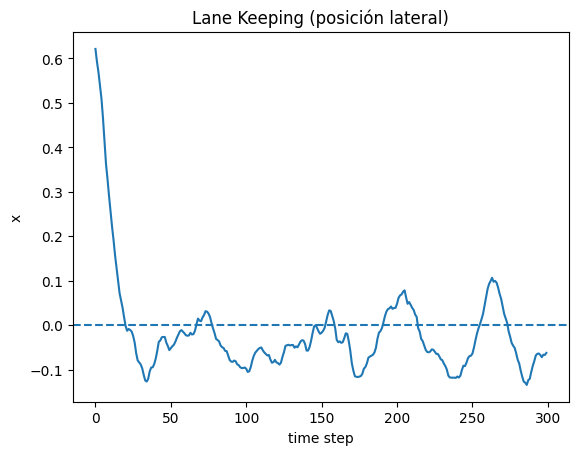

In [10]:


plt.plot(positions)
plt.axhline(0, linestyle="--")
plt.title("Lane Keeping (posición lateral)")
plt.xlabel("time step")
plt.ylabel("x")
plt.show()